In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from fafbseg import flywire
import pymaid
import navis as nv
import numpy as np
import seaborn as sns
import scipy.stats as stats
import statsmodels
import scikit_posthocs as sp
import sys
import scipy
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN


flywire.get_materialization_versions(dataset="production")

,time_stamp,id,is_merged,valid,version,status,datastack,expires_on
0,2026-07-16 05:10:00,1225,False,True,1234,AVAILABLE,flywire_fafb_production,2026-07-18 04:10:00
1,2026-07-14 05:10:00,1224,False,True,1233,AVAILABLE,flywire_fafb_production,2026-07-16 04:10:00
2,2023-09-30 05:10:00,773,False,True,783,AVAILABLE,flywire_fafb_production,2121-11-10 07:10:00
3,2023-03-21 08:10:00,619,True,True,630,AVAILABLE,flywire_fafb_production,2121-11-10 07:10:00
4,2022-01-17 08:10:00,247,True,True,258,AVAILABLE,flywire_fafb_production,2121-02-18 08:10:00


In [2]:
def get_cable_overlap(OSNs, PN = None, volume = None):
    neurons = flywire.skeletonize_neuron(OSNs)
    if volume:
        neurons = nv.in_volume(neurons, volume)
    
    if PN == None:
        cable_overlap = nv.cable_overlap(neurons, neurons, dist= "2 microns")
        return cable_overlap
    
    else:
        PN = flywire.skeletonize_neuron(PN)
        PN_cable_overlap = nv.cable_overlap(neurons, PN, dist= "2 microns")
        return PN_cable_overlap

def get_total_synapses(OSNs, volume = None):
    neurons = flywire.skeletonize_neuron(OSNs)
    if volume:
        neurons = nv.in_volume(neurons, volume) 
    return flywire.get_synapses(neurons, pre=True, post=False, attach=True, dataset='production', min_score=65,progress=False)    

def get_num_connectors(neuron1, neuron2):
    df = flywire.synapses.get_adjacency(neuron1, targets=neuron2, dataset='production', min_score=65, progress=True)
    return df.values[0][0]

def synapses_per_micron(cable_overlap_df, PN = None):
    cable_overlap_synapse_density = []
    for rowIndex, row in cable_overlap_df.iterrows(): #iterate over rows
        synapse_count = []
        cable_overlap_length = [] 
        for columnIndex, value in row.items():
            if value != 0:
                synapse_count.append(get_num_connectors(rowIndex, columnIndex))
                cable_overlap_length.append(value)
        cable_overlap_synapse_density.append(np.nanmean(np.array(synapse_count) / np.array(cable_overlap_length)) * 1000)   
    return pd.DataFrame(cable_overlap_synapse_density,columns=['overlap_density'], index=cable_overlap_df.index)

def get_neurons_without_overlap(cable_overlap_df):
    cable_overlap_df = cable_overlap_df.sum(axis=1)
    no_PN_overlap_neurons = [cable_overlap_df.index[index] for index, neuron in enumerate(cable_overlap_df) if neuron == 0.0]
    return no_PN_overlap_neurons

In [3]:
#load .ply files

dm1_l=nv.read_mesh("../glom_meshes/DM1_R.ply", output='volume') # DM1
v_l=nv.read_mesh("../glom_meshes/V_R.ply", output='volume') # V

gloms = ["DA4l", "DC1", "DL4", "DL5", "DM3","DM4", "DP1m", 
"VA2", "VA4", "VA6", "VA7l", "VC1", "VC2", "VL2a",
"VL2p", "VM4","DM1","V",
"D", 
"DA1",  
"DA2",  
"DA4m",  
"DC2", 
"DC3",  
"DL1", 
"DL2d",  
"DL3",  
"DM2",  
"DM5",  
"DM6",  
"DP1l", 
"VA1d",  
"VA1v",  
"VA3",  
"VA5", 
"VA7m", 
"VL1", 	
"VM1",  
"VM2",  
"VM3",  
"VM7d",  
"VM7v",  
"VM5d",
"DA3",
"DC4",
"DL2v",
"VC3",
'VC5',
'VM6',
"VC4",
"VM5v",
]

for glom in gloms:
    print(glom)
    exec(glom +"_mesh = nv.read_mesh(" + "'../glom_meshes/" + glom + "_R.ply' , output='volume')")

DA4l
DC1
DL4
DL5
DM3
DM4
DP1m
VA2
VA4
VA6
VA7l
VC1
VC2
VL2a
VL2p
VM4
DM1
V
D
DA1
DA2
DA4m
DC2
DC3
DL1
DL2d
DL3
DM2
DM5
DM6
DP1l
VA1d
VA1v
VA3
VA5
VA7m
VL1
VM1
VM2
VM3
VM7d
VM7v
VM5d
DA3
DC4
DL2v
VC3
VC5
VM6
VC4
VM5v


In [5]:
glom_volume = pd.read_csv("../csvs/fly_glomeruli_volume.csv")
glom_volume_single_uPN = pd.read_csv("../csvs/fly_glomeruli_volume_feedforward_single_uPN.csv")

In [6]:
glom_volume['glom_pn_type'] = ['single uPN','single uPN','single uPN','single uPN','single uPN','single uPN','single uPN',
                            'single uPN','single uPN','single uPN','single uPN','single uPN','single uPN','single uPN','single uPN','single uPN','single uPN',
                            'single uPN', 'multiple uPNs', 'multiple uPNs', 'multiple uPNs', 'multiple uPNs', 'multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs', 'multiple uPNs',
                            'multiple uPNs', 'multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs', 'multiple uPNs',
                            'multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs',
                            'multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs', 'multiple uPNs', 'single uPN','single uPN','single uPN']

glom_volume_single_uPN['glom_pn_type'] = ['single uPN','single uPN','single uPN','single uPN','single uPN','single uPN','single uPN','single uPN','single uPN','single uPN','single uPN','single uPN',
                            'single uPN','single uPN','single uPN','single uPN','single uPN','single uPN',
                            'single uPN','multiple uPNs', 'single uPN']   

In [8]:
glomeruli_list = ["ORN_V",      
]  
                  
glomeruli_OSNs = pd.DataFrame()
for glomeruli in glomeruli_list:
    if glomeruli in ['ORN_VC3','ORN_VC5','ORN_VM6']:
        annotation_search = flywire.search_annotations(flywire.NeuronCriteria(cell_type=glomeruli, annotation_version="v2.0.0"))
        #annotation_search = flywire.search_annotations(flywire.NeuronCriteria(cell_type=glomeruli, side='left', annotation_version="v2.0.0"))
    else:
        print(glomeruli)
        annotation_search = flywire.search_annotations(flywire.NeuronCriteria(hemibrain_type=glomeruli, annotation_version="v2.0.0"))
        #annotation_search = flywire.search_annotations(flywire.NeuronCriteria(hemibrain_type=glomeruli, side='left', annotation_version="v2.0.0"))
    print(f' for {glomeruli} {annotation_search.shape[0]} neurons were found')
    glomeruli_OSNs = pd.concat([glomeruli_OSNs, annotation_search])
    glomeruli_OSNs = glomeruli_OSNs[['root_id','hemibrain_type','cell_type']] #keep just the root_id and the glomeruli

ORN_V
Using annotation version "unspecified" (327ae7b) from https://github.com/flyconnectome/flywire_annotations.
Found 67 neurons matching the given criteria.
Using annotation version "latest tagged release" (a92610e from 2025-10-09) from https://github.com/flyconnectome/flywire_annotations.
Using materialization version 783.
 for ORN_V 67 neurons were found


In [29]:
V_bilateral_rightsoma_pn=720575940626143806
V_bilateral_leftsoma_pn=720575940630546540
V_unilateral_pn=720575940637910106
V_pn = [720575940626143806,720575940630546540,720575940637910106]

In [11]:
#the following neurons have no synapses with projection neurons in their glomerulus, so they were excluded from all analysis
neurons_to_exclude = [720575940642936520, 720575940623359466, 720575940633033133, 720575940621862605,
                      720575940605724081, 720575940604876977, 720575940630971434, 720575940632824531,
                      720575940611791834, 720575940614890642, 720575940642936520, 720575940611437973,
                      720575940614019112, 720575940615639199, 720575940639118653, 720575940615629173,
                      720575940621082138, 720575940608615363, 720575940630679749, 720575940628398791,
                      720575940639089571, 720575940634883179, 720575940638202852, 720575940614006934,
                      720575940603870688, 720575940632033875, 720575940632391736, 720575940623750852,
                      720575940622248709, 720575940631930415, 720575940613885506, 720575940627787343,
                      720575940624671490, 720575940631393823, 720575940619029589, 720575940623655605,
                      720575940630462572, 720575940619969329, 	
                    ]

In [12]:
glomeruli_OSNs = glomeruli_OSNs[~glomeruli_OSNs['root_id'].isin(neurons_to_exclude)]

In [13]:
glom_list = ["V"]
for glom in glom_list:
   retries = 5
   for retry in range(retries):
        try:
            print(glom)
            if glom in ['VM6']:
                exec(f"{glom}_feedforward_synapses = flywire.get_adjacency(glomeruli_OSNs[(glomeruli_OSNs['cell_type']=='ORN_{glom}v') | (glomeruli_OSNs['cell_type']=='ORN_{glom}l') | (glomeruli_OSNs['cell_type']=='ORN_{glom}m')]['root_id'], {glom}_pn, min_score=65, dataset='production').sum(axis=1)")
                exec(f"{glom}_total_synapses = get_total_synapses(glomeruli_OSNs[(glomeruli_OSNs['cell_type']=='ORN_{glom}v') | (glomeruli_OSNs['cell_type']=='ORN_{glom}l') | (glomeruli_OSNs['cell_type']=='ORN_{glom}m')]['root_id'], volume = {glom}_mesh)")
                exec(f"{glom}_feedforward = get_cable_overlap(glomeruli_OSNs[(glomeruli_OSNs['cell_type']=='ORN_{glom}v') | (glomeruli_OSNs['cell_type']=='ORN_{glom}l') | (glomeruli_OSNs['cell_type']=='ORN_{glom}m')]['root_id'],PN={glom}_pn, volume={glom}_mesh)")
            elif glom in ['VC3','VC5']:
                
                exec(f"{glom}_feedforward_synapses = flywire.get_adjacency(glomeruli_OSNs[glomeruli_OSNs['cell_type']=='ORN_{glom}']['root_id'], {glom}_pn, min_score=65, dataset='production').sum(axis=1)")
                exec(f"{glom}_total_synapses = get_total_synapses(glomeruli_OSNs[glomeruli_OSNs['cell_type']=='ORN_{glom}']['root_id'], volume = {glom}_mesh)")
                exec(f"{glom}_feedforward = get_cable_overlap(glomeruli_OSNs[glomeruli_OSNs['cell_type']=='ORN_{glom}']['root_id'],PN={glom}_pn, volume={glom}_mesh)")
            else:
              exec(f"{glom}_feedforward_synapses = flywire.get_adjacency(glomeruli_OSNs[glomeruli_OSNs['hemibrain_type']=='ORN_{glom}']['root_id'], {glom}_pn, min_score=65, dataset='production').sum(axis=1)")
              exec(f"{glom}_total_synapses = get_total_synapses(glomeruli_OSNs[glomeruli_OSNs['hemibrain_type']=='ORN_{glom}']['root_id'], volume = {glom}_mesh)")
              exec(f"{glom}_feedforward = get_cable_overlap(glomeruli_OSNs[glomeruli_OSNs['hemibrain_type']=='ORN_{glom}']['root_id'],PN={glom}_pn, volume={glom}_mesh)")
            exec(f"{glom}_feedforward_synapses_per_micron = synapses_per_micron({glom}_feedforward,PN={glom}_pn)")
        except:
            if retry < retries - 1:
                print(f'number of retries left = {retries-retry}')
                continue
            else:
                raise
        break
   

V
Using materialization version 1234.


Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


Skeletonizing:   0%|          | 0/67 [00:00<?, ?it/s]

Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved 

Copy:   0%|          | 0/67 [00:00<?, ?it/s]

...

Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


Using materialization version 1234.


Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


Using materialization version 1234.


C:\Users\wesle\AppData\Local\Temp\ipykernel_9892\803120219.py:34: RuntimeWarning: Mean of empty slice
  cable_overlap_synapse_density.append(np.nanmean(np.array(synapse_count) / np.array(cable_overlap_length)) * 1000)


In [ ]:
V_bilateral_rightsoma_feedforward_synapses = flywire.get_adjacency(glomeruli_OSNs[glomeruli_OSNs['hemibrain_type']=='ORN_V']['root_id'], V_bilateral_rightsoma_pn, min_score=65, dataset='production').sum(axis=1)
V_bilateral_rightsoma_feedforward = get_cable_overlap(glomeruli_OSNs[glomeruli_OSNs['hemibrain_type']=='ORN_V']['root_id'],PN=V_bilateral_rightsoma_pn,volume=V_mesh)
V_bilateral_rightsoma_feedforward_synapses_per_micron = synapses_per_micron(V_bilateral_rightsoma_feedforward,PN=V_bilateral_rightsoma_pn)

Using materialization version 1234.


Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


Skeletonizing:   0%|          | 0/67 [00:00<?, ?it/s]

Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved 

Copy:   0%|          | 0/67 [00:00<?, ?it/s]

...

Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


Using materialization version 1234.


Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


Using materialization version 1234.


C:\Users\wesle\AppData\Local\Temp\ipykernel_9892\803120219.py:34: RuntimeWarning: Mean of empty slice
  cable_overlap_synapse_density.append(np.nanmean(np.array(synapse_count) / np.array(cable_overlap_length)) * 1000)


In [15]:
V_bilateral_leftsoma_feedforward_synapses = flywire.get_adjacency(glomeruli_OSNs[glomeruli_OSNs['hemibrain_type']=='ORN_V']['root_id'], V_bilateral_leftsoma_pn, min_score=65, dataset='production').sum(axis=1)
V_bilateral_leftsoma_feedforward = get_cable_overlap(glomeruli_OSNs[glomeruli_OSNs['hemibrain_type']=='ORN_V']['root_id'],PN=V_bilateral_leftsoma_pn,volume=V_mesh)
V_bilateral_leftsoma_feedforward_synapses_per_micron = synapses_per_micron(V_bilateral_leftsoma_feedforward,PN=V_bilateral_leftsoma_pn)

Using materialization version 1234.


Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


Skeletonizing:   0%|          | 0/67 [00:00<?, ?it/s]

Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved 

Copy:   0%|          | 0/67 [00:00<?, ?it/s]

...

Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


Using materialization version 1234.


Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


Using materialization version 1234.


C:\Users\wesle\AppData\Local\Temp\ipykernel_9892\803120219.py:34: RuntimeWarning: Mean of empty slice
  cable_overlap_synapse_density.append(np.nanmean(np.array(synapse_count) / np.array(cable_overlap_length)) * 1000)


In [16]:
V_unilateral_feedforward_synapses = flywire.get_adjacency(glomeruli_OSNs[glomeruli_OSNs['hemibrain_type']=='ORN_V']['root_id'], V_unilateral_pn, min_score=65, dataset='production').sum(axis=1)
V_unilateral_feedforward = get_cable_overlap(glomeruli_OSNs[glomeruli_OSNs['hemibrain_type']=='ORN_V']['root_id'],PN=V_unilateral_pn,volume=V_mesh)
V_unilateral_feedforward_synapses_per_micron = synapses_per_micron(V_unilateral_feedforward,PN=V_unilateral_pn)


Using materialization version 1234.


Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


Skeletonizing:   0%|          | 0/67 [00:00<?, ?it/s]

Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved 

Copy:   0%|          | 0/67 [00:00<?, ?it/s]

...

Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


Using materialization version 1234.


Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


Using materialization version 1234.


C:\Users\wesle\AppData\Local\Temp\ipykernel_9892\803120219.py:34: RuntimeWarning: Mean of empty slice
  cable_overlap_synapse_density.append(np.nanmean(np.array(synapse_count) / np.array(cable_overlap_length)) * 1000)


In [18]:
V_total_feedforward_synapses = flywire.get_adjacency(glomeruli_OSNs[glomeruli_OSNs['hemibrain_type']=='ORN_V']['root_id'], [V_bilateral_leftsoma_pn,V_bilateral_rightsoma_pn,V_unilateral_pn], min_score=65, dataset='production').sum(axis=1)
V_total_feedforward = get_cable_overlap(glomeruli_OSNs[glomeruli_OSNs['hemibrain_type']=='ORN_V']['root_id'], PN=[V_bilateral_leftsoma_pn,V_bilateral_rightsoma_pn,V_unilateral_pn],volume=V_mesh)
V_total_feedforward_synapses_per_micron = synapses_per_micron(V_total_feedforward,PN=[V_bilateral_leftsoma_pn,V_bilateral_rightsoma_pn,V_unilateral_pn])

Using materialization version 1234.


Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


Skeletonizing:   0%|          | 0/67 [00:00<?, ?it/s]

Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved 

Copy:   0%|          | 0/67 [00:00<?, ?it/s]

...

Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


Using materialization version 1234.


Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


Using materialization version 1234.


C:\Users\wesle\AppData\Local\Temp\ipykernel_9892\803120219.py:34: RuntimeWarning: Mean of empty slice
  cable_overlap_synapse_density.append(np.nanmean(np.array(synapse_count) / np.array(cable_overlap_length)) * 1000)


In [19]:
v_density_data = pd.DataFrame({'V bilateral left': V_bilateral_leftsoma_feedforward_synapses_per_micron['overlap_density'],
                                  'V bilateral right': V_bilateral_rightsoma_feedforward_synapses_per_micron['overlap_density'],
                                  'V unilateral': V_unilateral_feedforward_synapses_per_micron['overlap_density'],
    'V_total': V_total_feedforward_synapses_per_micron['overlap_density']})


In [32]:
v_synapse_count_data = pd.DataFrame({'V bilateral left': V_bilateral_leftsoma_feedforward_synapses,
                                  'V bilateral right': V_bilateral_rightsoma_feedforward_synapses,
                                  'V unilateral': V_unilateral_feedforward_synapses,
    'V_total': V_total_feedforward_synapses})

In [33]:
v_synapse_count_data

,V bilateral left,V bilateral right,V unilateral,V_total
source,,,,
720575940614548253,30.0,31.0,9.0,70.0
720575940652581878,3.0,1.0,0.0,4.0
720575940617067305,29.0,28.0,16.0,73.0
720575940641592973,14.0,19.0,0.0,33.0
720575940614548765,39.0,38.0,14.0,91.0
...,...,...,...,...
720575940620411764,1.0,2.0,1.0,4.0
720575940606053041,4.0,3.0,0.0,7.0
720575940627265043,2.0,2.0,0.0,4.0


In [34]:
v_density_data_long = pd.melt(v_density_data)
v_synapse_count_data_long = pd.melt(v_synapse_count_data)

In [35]:
v_density_data_long = v_density_data_long[v_density_data_long['value'].notna()]
V_synapse_count_data_long = v_synapse_count_data_long[v_synapse_count_data_long['value'].notna()]

In [24]:
# start here if loaded pre-generated flyneurons dataframe

import matplotlib as mpl
import warnings
from seaborn.categorical import _CategoricalPlotter
from seaborn.utils import (
    desaturate,
    _check_argument,
    _draw_figure,
    _default_color,
    _get_patch_legend_artist,
    _get_transform_functions,
    _scatter_legend_artist,
    _version_predates,
)
from seaborn._core.typing import default, deprecated
from seaborn._stats.density import KDE
class MyCategoricalPlotter(_CategoricalPlotter):

    def plot_violins(
        self,
        width,
        dodge,
        gap,
        split,
        color,
        fill,
        linecolor,
        linewidth,
        inner,
        density_norm,
        common_norm,
        kde_kws,
        inner_kws,
        plot_kws,
    ):
        iter_vars = [self.orient, "hue"]
        value_var = {"x": "y", "y": "x"}[self.orient]

        inner_options = ["box","line_quart", "quart", "stick", "point", None]
        _check_argument("inner", inner_options, inner, prefix=True)
        _check_argument("density_norm", ["area", "count", "width"], density_norm)

        if linewidth is None:
            if fill:
                linewidth = 1.25 * mpl.rcParams["patch.linewidth"]
            else:
                linewidth = mpl.rcParams["lines.linewidth"]

        if inner is not None and inner.startswith("box"):
            box_width = inner_kws.pop("box_width", linewidth * 4.5)
            whis_width = inner_kws.pop("whis_width", box_width / 3)
            marker = inner_kws.pop("marker", "_" if self.orient == "x" else "|")

        kde = KDE(**kde_kws)
        ax = self.ax
        violin_data = []

        # Iterate through all the data splits once to compute the KDEs
        for sub_vars, sub_data in self.iter_data(iter_vars,
                                                 from_comp_data=True,
                                                 allow_empty=False):

            sub_data["weight"] = sub_data.get("weights", 1)
            stat_data = kde._transform(sub_data, value_var, [])

            maincolor = self._hue_map(sub_vars["hue"]) if "hue" in sub_vars else color
            if not fill:
                linecolor = maincolor
                maincolor = "none"
            default_kws = dict(
                facecolor=maincolor,
                edgecolor=linecolor,
                linewidth=linewidth,
            )

            violin_data.append({
                "position": sub_vars[self.orient],
                "observations": sub_data[value_var],
                "density": stat_data["density"],
                "support": stat_data[value_var],
                "kwargs": {**default_kws, **plot_kws},
                "sub_vars": sub_vars,
                "ax": self._get_axes(sub_vars),
            })

        # Once we've computed all the KDEs, get statistics for normalization
        def vars_to_key(sub_vars):
            return tuple((k, v) for k, v in sub_vars.items() if k != self.orient)

        norm_keys = [vars_to_key(violin["sub_vars"]) for violin in violin_data]
        if common_norm:
            common_max_density = np.nanmax([v["density"].max() for v in violin_data])
            common_max_count = np.nanmax([len(v["observations"]) for v in violin_data])
            max_density = {key: common_max_density for key in norm_keys}
            max_count = {key: common_max_count for key in norm_keys}
        else:
            with warnings.catch_warnings():
                # Ignore warning when all violins are singular; it's not important
                warnings.filterwarnings('ignore', "All-NaN (slice|axis) encountered")
                max_density = {
                    key: np.nanmax([
                        v["density"].max() for v in violin_data
                        if vars_to_key(v["sub_vars"]) == key
                    ]) for key in norm_keys
                }
            max_count = {
                key: np.nanmax([
                    len(v["observations"]) for v in violin_data
                    if vars_to_key(v["sub_vars"]) == key
                ]) for key in norm_keys
            }

        real_width = width * self._native_width

        # Now iterate through the violins again to apply the normalization and plot
        for violin in violin_data:

            index = pd.RangeIndex(0, max(len(violin["support"]), 1))
            data = pd.DataFrame({
                self.orient: violin["position"],
                value_var: violin["support"],
                "density": violin["density"],
                "width": real_width,
            }, index=index)

            if dodge:
                self._dodge(violin["sub_vars"], data)
            if gap:
                data["width"] *= 1 - gap

            # Normalize the density across the distribution(s) and relative to the width
            norm_key = vars_to_key(violin["sub_vars"])
            hw = data["width"] / 2
            peak_density = violin["density"].max()
            if np.isnan(peak_density):
                span = 1
            elif density_norm == "area":
                span = data["density"] / max_density[norm_key]
            elif density_norm == "count":
                count = len(violin["observations"])
                span = data["density"] / peak_density * (count / max_count[norm_key])
            elif density_norm == "width":
                span = data["density"] / peak_density
            span = span * hw * (2 if split else 1)

            # Handle split violins (i.e. asymmetric spans)
            right_side = (
                0 if "hue" not in self.variables
                else self._hue_map.levels.index(violin["sub_vars"]["hue"]) % 2
            )
            if split:
                offsets = (hw, span - hw) if right_side else (span - hw, hw)
            else:
                offsets = span, span

            ax = violin["ax"]
            _, invx = _get_transform_functions(ax, "x")
            _, invy = _get_transform_functions(ax, "y")
            inv_pos = {"x": invx, "y": invy}[self.orient]
            inv_val = {"x": invx, "y": invy}[value_var]

            linecolor = violin["kwargs"]["edgecolor"]

            # Handle singular datasets (one or more observations with no variance
            if np.isnan(peak_density):
                pos = data[self.orient].iloc[0]
                val = violin["observations"].mean()
                if self.orient == "x":
                    x, y = [pos - offsets[0], pos + offsets[1]], [val, val]
                else:
                    x, y = [val, val], [pos - offsets[0], pos + offsets[1]]
                ax.plot(invx(x), invy(y), color=linecolor, linewidth=linewidth)
                continue

            # Plot the main violin body
            plot_func = {"x": ax.fill_betweenx, "y": ax.fill_between}[self.orient]
            plot_func(
                inv_val(data[value_var]),
                inv_pos(data[self.orient] - offsets[0]),
                inv_pos(data[self.orient] + offsets[1]),
                **violin["kwargs"]
            )

            # Adjust the observation data
            obs = violin["observations"]
            pos_dict = {self.orient: violin["position"], "width": real_width}
            if dodge:
                self._dodge(violin["sub_vars"], pos_dict)
            if gap:
                pos_dict["width"] *= (1 - gap)

            # --- Plot the inner components
            if inner is None:
                continue

            elif inner.startswith("point"):
                pos = np.array([pos_dict[self.orient]] * len(obs))
                if split:
                    pos += (-1 if right_side else 1) * pos_dict["width"] / 2
                x, y = (pos, obs) if self.orient == "x" else (obs, pos)
                kws = {
                    "color": linecolor,
                    "edgecolor": linecolor,
                    "s": (linewidth * 2) ** 2,
                    "zorder": violin["kwargs"].get("zorder", 2) + 1,
                    **inner_kws,
                }
                ax.scatter(invx(x), invy(y), **kws)

            elif inner.startswith("stick"):
                pos0 = np.interp(obs, data[value_var], data[self.orient] - offsets[0])
                pos1 = np.interp(obs, data[value_var], data[self.orient] + offsets[1])
                pos_pts = np.stack([inv_pos(pos0), inv_pos(pos1)])
                val_pts = np.stack([inv_val(obs), inv_val(obs)])
                segments = np.stack([pos_pts, val_pts]).transpose(2, 1, 0)
                if self.orient == "y":
                    segments = segments[:, :, ::-1]
                kws = {
                    "color": linecolor,
                    "linewidth": linewidth / 2,
                    **inner_kws,
                }
                lines = mpl.collections.LineCollection(segments, **kws)
                ax.add_collection(lines, autolim=False)

            elif inner.startswith("quart"):
                stats = np.percentile(obs, [25, 50, 75])
                pos0 = np.interp(stats, data[value_var], data[self.orient] - offsets[0])
                pos1 = np.interp(stats, data[value_var], data[self.orient] + offsets[1])
                pos_pts = np.stack([inv_pos(pos0), inv_pos(pos1)])
                val_pts = np.stack([inv_val(stats), inv_val(stats)])
                segments = np.stack([pos_pts, val_pts]).transpose(2, 0, 1)
                if self.orient == "y":
                    segments = segments[:, ::-1, :]
                dashes = [(1.25, .75), (2.5, 1), (1.25, .75)]
                for i, segment in enumerate(segments):
                    kws = {
                        "color": linecolor,
                        "linewidth": linewidth,
                        "dashes": dashes[i],
                        **inner_kws,
                    }
                    ax.plot(*segment, **kws)

            elif inner.startswith("line_quart"):
                stats = np.percentile(obs, [50])
                pos0 = np.interp(stats, data[value_var], data[self.orient] - offsets[0])
                pos1 = np.interp(stats, data[value_var], data[self.orient] + offsets[1])
                pos_pts = np.stack([inv_pos(pos0), inv_pos(pos1)])
                val_pts = np.stack([inv_val(stats), inv_val(stats)])
                segments = np.stack([pos_pts, val_pts]).transpose(2, 0, 1)
                if self.orient == "y":
                    segments = segments[:, ::-1, :]
                #dashes = [(1.25, .75), (2.5, 1), (1.25, .75)]
                for i, segment in enumerate(segments):
                    kws = {
                        "color": 'black',
                        "linewidth": linewidth,
                        #"dashes": dashes[i],
                        **inner_kws,
                    }
                    ax.plot(*segment, **kws)


            elif inner.startswith("box"):
                stats = mpl.cbook.boxplot_stats(obs)[0]
                pos = np.array(pos_dict[self.orient])
                if split:
                    pos += (-1 if right_side else 1) * pos_dict["width"] / 2
                pos = [pos, pos], [pos, pos], [pos]
                val = (
                    [stats["whislo"], stats["whishi"]],
                    [stats["q1"], stats["q3"]],
                    [stats["med"]]
                )
                if self.orient == "x":
                    (x0, x1, x2), (y0, y1, y2) = pos, val
                else:
                    (x0, x1, x2), (y0, y1, y2) = val, pos

                if split:
                    offset = (1 if right_side else -1) * box_width / 72 / 2
                    dx, dy = (offset, 0) if self.orient == "x" else (0, -offset)
                    trans = ax.transData + mpl.transforms.ScaledTranslation(
                        dx, dy, ax.figure.dpi_scale_trans,
                    )
                else:
                    trans = ax.transData
                line_kws = {
                    "color": linecolor,
                    "transform": trans,
                    **inner_kws,
                    "linewidth": whis_width,
                }
                ax.plot(invx(x0), invy(y0), **line_kws)
                line_kws["linewidth"] = box_width
                ax.plot(invx(x1), invy(y1), **line_kws)
                dot_kws = {
                    "marker": marker,
                    "markersize": box_width / 1.2,
                    "markeredgewidth": box_width / 5,
                    "transform": trans,
                    **inner_kws,
                    "markeredgecolor": "w",
                    "markerfacecolor": "w",
                    "color": linecolor,  # simplify tests
                }
                ax.plot(invx(x2), invy(y2), **dot_kws)

        legend_artist = _get_patch_legend_artist(fill)
        common_kws = {**plot_kws, "linewidth": linewidth, "edgecolor": linecolor}
        self._configure_legend(ax, legend_artist, common_kws)


def my_violinplot(
    data=None, *, x=None, y=None, hue=None, order=None, hue_order=None,
    orient=None, color=None, palette=None, saturation=.75, fill=True,
    inner="box", split=False, width=.8, dodge="auto", gap=0,
    linewidth=None, linecolor="auto", cut=2, gridsize=100,
    bw_method="scott", bw_adjust=1, density_norm="area", common_norm=False,
    hue_norm=None, formatter=None, log_scale=None, native_scale=False,
    legend="auto", scale=deprecated, scale_hue=deprecated, bw=deprecated,
    inner_kws=None, ax=None, **kwargs,
):

    p = MyCategoricalPlotter(
        data=data,
        variables=dict(x=x, y=y, hue=hue),
        order=order,
        orient=orient,
        color=color,
        legend=legend,
    )

    if ax is None:
        ax = plt.gca()

    if p.plot_data.empty:
        return ax

    if dodge == "auto":
        # Needs to be before scale_categorical changes the coordinate series dtype
        dodge = p._dodge_needed()

    if p.var_types.get(p.orient) == "categorical" or not native_scale:
        p.scale_categorical(p.orient, order=order, formatter=formatter)

    p._attach(ax, log_scale=log_scale)

    # Deprecations to remove in v0.14.0.
    hue_order = p._palette_without_hue_backcompat(palette, hue_order)
    palette, hue_order = p._hue_backcompat(color, palette, hue_order)

    saturation = saturation if fill else 1
    p.map_hue(palette=palette, order=hue_order, norm=hue_norm, saturation=saturation)
    color = _default_color(
        ax.fill_between, hue, color,
        {k: v for k, v in kwargs.items() if k in ["c", "color", "fc", "facecolor"]},
        saturation=saturation,
    )
    linecolor = p._complement_color(linecolor, color, p._hue_map)

    density_norm, common_norm = p._violin_scale_backcompat(
        scale, scale_hue, density_norm, common_norm,
    )

    bw_method = p._violin_bw_backcompat(bw, bw_method)
    kde_kws = dict(cut=cut, gridsize=gridsize, bw_method=bw_method, bw_adjust=bw_adjust)
    inner_kws = {} if inner_kws is None else inner_kws.copy()

    p.plot_violins(
        width=width,
        dodge=dodge,
        gap=gap,
        split=split,
        color=color,
        fill=fill,
        linecolor=linecolor,
        linewidth=linewidth,
        inner=inner,
        density_norm=density_norm,
        common_norm=common_norm,
        kde_kws=kde_kws,
        inner_kws=inner_kws,
        plot_kws=kwargs,
    )

    p._add_axis_labels(ax)
    p._adjust_cat_axis(ax, axis=p.orient)

    return ax  

findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberati

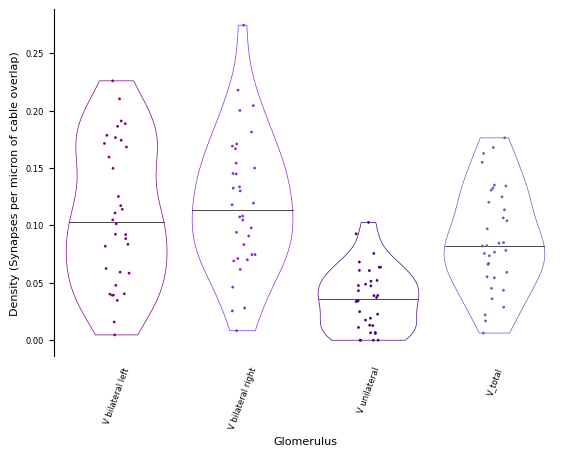

In [25]:
violinplot_dims = (6.5, 4.5)
custom_palette=[ "purple","blueviolet", 'indigo', 'slateblue']
fig, ax = plt.subplots(figsize=violinplot_dims)
my_violinplot(v_density_data_long, x='variable',y='value', fill=False, inner='line_quart', cut=0, linewidth=0.5,scale='width',palette=custom_palette)

ax = sns.stripplot(v_density_data_long, x='variable',y='value', size=2, palette=custom_palette, legend=None)
ax.set_ylabel("Density (Synapses per micron of cable overlap)", size=8)
ax.set_xlabel('Glomerulus', size=8, fontname="Liberation Sans")
plt.xticks(fontsize=6, fontname="Liberation Sans")
plt.yticks(fontsize=6, fontname="Liberation Sans")
#ax.set_aspect(0.01)
#plt.ylim(0,370)
plt.xticks(rotation=70)
plt.tick_params(axis='x', which='both', bottom=False, top=False)
plt.tick_params(axis='y', which='both', left=True, right=False)
sns.despine(fig=None, ax=None, top=True, right=True, left=False, bottom=True, offset=None, trim=False)

plt.savefig('../svgs/feedforwardDensity_V_glomeruli.svg', format="svg")
plt.show()

findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberati

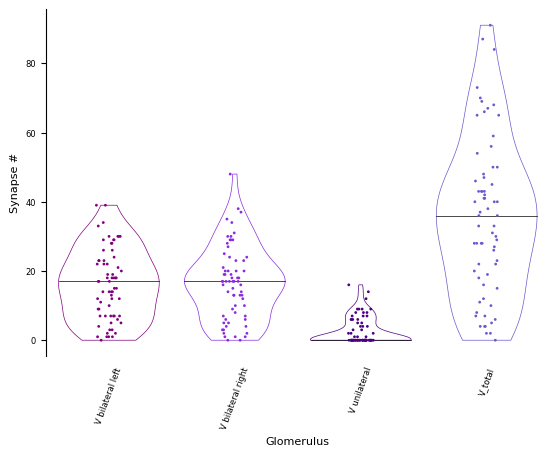

In [36]:
violinplot_dims = (6.5, 4.5)
custom_palette=[ "purple","blueviolet", 'indigo', 'slateblue']
fig, ax = plt.subplots(figsize=violinplot_dims)
my_violinplot(v_synapse_count_data_long, x='variable',y='value', fill=False, inner='line_quart', cut=0, linewidth=0.5,scale='width',palette=custom_palette)

ax = sns.stripplot(v_synapse_count_data_long, x='variable',y='value', size=2, palette=custom_palette, legend=None)
ax.set_ylabel("Synapse #", size=8)
ax.set_xlabel('Glomerulus', size=8, fontname="Liberation Sans")
plt.xticks(fontsize=6, fontname="Liberation Sans")
plt.yticks(fontsize=6, fontname="Liberation Sans")
#ax.set_aspect(0.01)
#plt.ylim(0,370)
plt.xticks(rotation=70)
plt.tick_params(axis='x', which='both', bottom=False, top=False)
plt.tick_params(axis='y', which='both', left=True, right=False)
sns.despine(fig=None, ax=None, top=True, right=True, left=False, bottom=True, offset=None, trim=False)

plt.savefig('../svgs/feedforwardSynapse_Count_V_glomeruli.svg', format="svg")
plt.show()

In [27]:
v_feedforward_synapse_count_post_hoc = sp.posthoc_dunn(V_synapse_count_data_long,val_col='value',group_col='variable',p_adjust="bonferroni")
v_feedforward_synapse_count_post_hoc


,V bilateral left,V bilateral right,V unilateral,V_total
V bilateral left,1.000000e+00,1.000000e+00,1.824414e-11,1.968885e-04
V bilateral right,1.000000e+00,1.000000e+00,1.513178e-11,2.207535e-04
V unilateral,1.824414e-11,1.513178e-11,1.000000e+00,5.449265e-28
V_total,1.968885e-04,2.207535e-04,5.449265e-28,1.000000e+00


In [28]:
v_feedforward_density_post_hoc = sp.posthoc_dunn(v_density_data_long,val_col='value',group_col='variable',p_adjust="bonferroni")
v_feedforward_density_post_hoc

,V bilateral left,V bilateral right,V unilateral,V_total
V bilateral left,1.000000e+00,1.000000e+00,4.555339e-07,1.000000
V bilateral right,1.000000e+00,1.000000e+00,1.130662e-08,0.436651
V unilateral,4.555339e-07,1.130662e-08,1.000000e+00,0.000151
V_total,1.000000e+00,4.366507e-01,1.510474e-04,1.000000
